3 - O eletrocardiograma (ECG) é um sinal de importância vital para o estudo dos fenômenos bioelétricos. Em particular, o ECG contém informações para o diagnóstico de doenças cardiovasculares, já que esse reflete o comportamento biológico do coração. Os sinais elétricos gerados pelo coração podem ser capturados através de eletrodos posicionados no corpo do paciente. Cada trecho de um ciclo de eletrocardiograma foi classificado de acordo com o formato de cada onda e é dividido em onda P, complexo QRS, onda T e ocasionalmente onda U. A análise de um ECG é baseada em inspeção visual e identificação do complexo QRS, que determina o início da contração do ventrículo esquerdo. Todavia, em alguns casos, a análise visual do ECG é complexa, o que levou ao desenvolvimento de algoritmos computacionais capazes de detectar o complexo QRS de um ECG. Dentre os algoritmos para detecção do complexo QRS encontra-se o método de **Ahlstrom e Tompkins (1983)**, baseado na primeira e segunda derivada. Sendo \(x[n]\) o sinal de ECG, no método de Ahlstrom e Tompkins primeiro calcula-se a **primeira derivada retificada**:

$$
y_0[n] = |x[n+1] - x[n-1]|
$$

Após isso, a primeira derivada retificada é **suavizada**:

$$
y_1[n] = \frac{y_0[n-1] + 2y_0[n] + y_0[n+1]}{4}
$$

A **segunda derivada retificada** é calculada como:

$$
y_2[n] = |x[n+2] - 2x[n] + x[n-2]|
$$

A primeira derivada retificada e suavizada é então somada à segunda derivada retificada:

$$
y_3[n] = 2(y_1[n] + y_2[n])
$$

O valor máximo de $y_3[n]$ é determinado e utilizado para definir o **limiar primário** $\lambda_1$ e **secundário** $\lambda_2$:

$$
\lambda_1 = 0{,}5 \max\{y_3[n]\}
$$

$$
\lambda_2 = 0{,}1 \max\{y_3[n]\}
$$

A sequência $y_3[n]$ é percorrida até que seja encontrada uma amostra que exceda o limiar primário, a qual será classificada como um possível complexo QRS. Para que o complexo seja confirmado, as próximas seis amostras consecutivas devem ser maiores ou iguais ao limiar secundário. De forma a minimizar erros devido ao início do processamento (enquanto existem valores em transientes resultantes do processo de captura), recomenda-se descartar o primeiro 1 s de captura do sinal de ECG, de forma a detectar adequadamente os limiares primários e secundários. **Diante disso:**  


(a) Implemente esse algoritmo em Matlab ou em Python. Considere que o sinal  ́e obtido atrav ́es de um
processo de amostragem com taxa de amostragem de 200 Hz.

In [8]:
import pandas as pd
df = pd.read_csv('100_norm.csv', header=None)
print(df.shape)
print(df.head(10))

(650000, 3)
       0      1      2
0  0.000 -0.145 -0.065
1  0.003 -0.145 -0.065
2  0.006 -0.145 -0.065
3  0.008 -0.145 -0.065
4  0.011 -0.145 -0.065
5  0.014 -0.145 -0.065
6  0.017 -0.145 -0.065
7  0.019 -0.145 -0.065
8  0.022 -0.120 -0.080
9  0.025 -0.135 -0.080


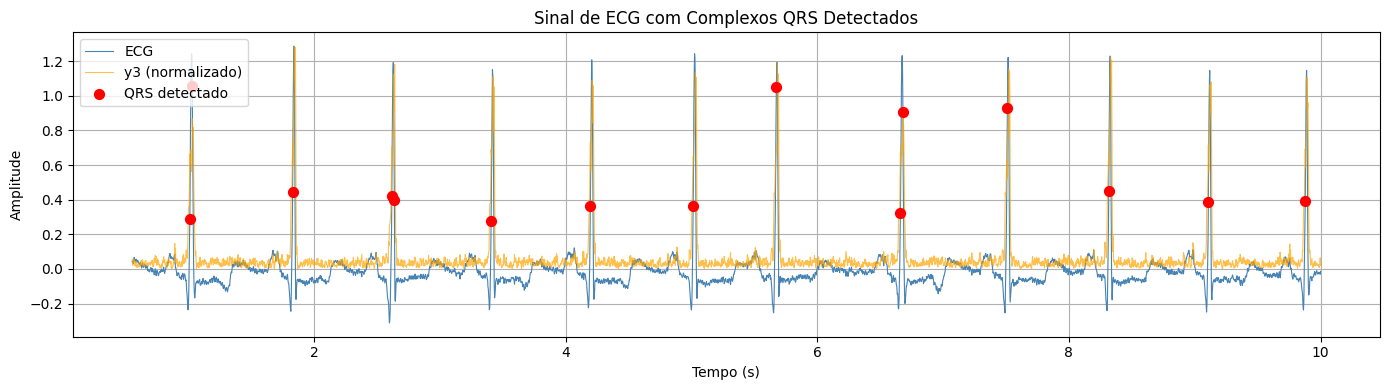

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt

# Carregamento correto do CSV
df = pd.read_csv('100_norm.csv', header=None)
t_raw = df[0].values
x_raw = df[1].values

# Primeiros 10 segundos
mask = t_raw <= 10
t_sinal = t_raw[mask]
x_raw = x_raw[mask]

# Remove drift de linha de base
fs = 200
b, a = butter(2, 0.5 / (fs / 2), btype='high')
x = filtfilt(b, a, x_raw)

n = np.arange(len(x))
fs_idx = fs # índice correspondente a 1s real

# y0: primeira derivada retificada
y0 = np.zeros(len(n))
for i in range(len(n)):
    x_sub = x[i-1] if i > 0 else 0
    x_add = x[i+1] if i < len(n)-1 else 0
    y0[i] = abs(x_add - x_sub)

# y1: suavização da primeira derivada
y1 = np.zeros(len(n))
for i in range(len(n)):
    y0_sub = y0[i-1] if i > 0 else 0
    y0_add = y0[i+1] if i < len(n)-1 else 0
    y1[i] = (y0_sub + 2*y0[i] + y0_add) / 4

# y2: segunda derivada retificada
y2 = np.zeros(len(n))
for i in range(len(n)):
    x_sub = x[i-2] if i >= 2 else 0
    x_add = x[i+2] if i <= len(n)-3 else 0
    y2[i] = abs(x_add - 2*x[i] + x_sub)

# y3: combinação
y3 = 2 * (y1 + y2)

# Limiares descartando o primeiro 1s real
lambda_1 = 0.5 * np.max(y3[fs_idx:])
lambda_2 = 0.1 * np.max(y3[fs_idx:])

# Detecção QRS
qrs_markers = np.zeros(len(n))
i = fs_idx
while i < len(n):
    if y3[i] > lambda_1:
        if i + 6 < len(n):
            if np.all(y3[i+1:i+7] >= lambda_2):
                qrs_markers[i] = 1
                i += 7
                continue
    i += 1

# Gráfico
qrs_indices = np.where(qrs_markers[fs_idx:] == 1)[0] + fs_idx

plt.figure(figsize=(14, 4))
plt.plot(t_sinal[fs_idx:], x[fs_idx:], color='steelblue', linewidth=0.8, label='ECG')
plt.plot(t_sinal[fs_idx:], y3[fs_idx:] / max(y3[fs_idx:]) * max(abs(x)), 
         color='orange', linewidth=0.8, alpha=0.7, label='y3 (normalizado)')
plt.scatter(t_sinal[qrs_indices], x[qrs_indices], color='red', zorder=5, s=50, label='QRS detectado')
plt.ylabel('Amplitude')
plt.xlabel('Tempo (s)')
plt.title('Sinal de ECG com Complexos QRS Detectados')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

B) Verifique o funcionamento do algoritmo implementado. Utilize o sinal 100 norm.matou 100 norm.csv
fornecido em anexo. Como resultado, deseja-se apresentar, em um mesmo gr ́afico, o sinal de ECG e
um outro gr ́afico, que demarca a posic ̧  ̃ao dos complexos QR

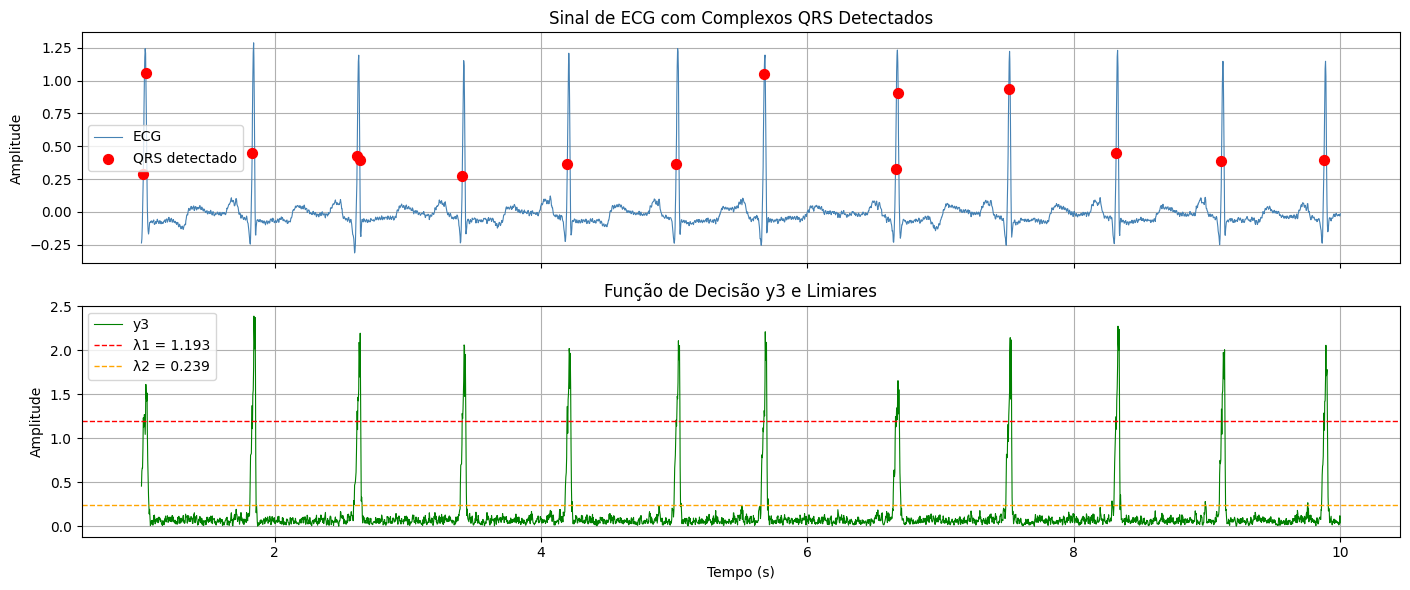

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Painel 1: ECG com bolinhas nos QRS
axes[0].plot(t_sinal[fs_idx:], x[fs_idx:], color='steelblue', linewidth=0.8, label='ECG')
axes[0].scatter(t_sinal[qrs_indices], x[qrs_indices], color='red', zorder=5, s=50, label='QRS detectado')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Sinal de ECG com Complexos QRS Detectados')
axes[0].legend()
axes[0].grid(True)

# Painel 2: y3 com limiares
axes[1].plot(t_sinal[fs_idx:], y3[fs_idx:], color='green', linewidth=0.8, label='y3')
axes[1].axhline(lambda_1, color='red',   linestyle='--', linewidth=1, label=f'λ1 = {lambda_1:.3f}')
axes[1].axhline(lambda_2, color='orange',linestyle='--', linewidth=1, label=f'λ2 = {lambda_2:.3f}')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Tempo (s)')
axes[1].set_title('Função de Decisão y3 e Limiares')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()